# Calcium Aluminosilicate Glass Simulation with Pedone PMMCS Potential
This notebook is designed to showcase the implementations of the pyiron_glass package for simulating multi-component glasses with classical interatomic potentials.
It will be further extended to include more complex simulations and analyses.


## Potential and Elements
Simulations implemented so far are based on the PMMCS interatomic potential from A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018.
The PMMCS potential makes use of 2-body MORSE interactions between oxygen and cations, electrostatic interactions based on scaled partial charges (i.e., O=-1.2, Na=0.6, Mg=1.2, Al=1.8) among all ions, and a repulsive short-range term. It was originally fitted to reproduce the experimental crystal structures and elastic constants of oxides, silicates, and aluminosilicates.

The supported elements in alphabetical order are:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

The cations can be classified into three categories:
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

Typical compositions the potential can handle include:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems


## Standard Melt-Quenching Protocol and Parameters
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: heating from 300 to 5000 K with a constant heating rate (here: on the order of 1-10 K/ps)
2. NVT: equilibration of the melt at 5000 K for 100 ps (NVT ensemble)
3. NVT: cooling with down to 300 K (again with 1-10 K/ps)
4. NpT: equilibration at 300 K to relax the stress
5. NVT: extended equilibration at 300 K to extract thermodynamic and structural properties

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project


from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

# Example Melt-Quenching Simulation

In [2]:
# Definition of the pyiron project, generating an initial random structure and setting up the potential information
pr = Project("glass")
atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2",
    n_molecules=100,
    density=2.69 * 1.0,
    min_distance=1.8,
    max_attempts_per_atom=10000,
    pyiron_project=pr,
)
structure = get_ase_structure(
    atoms_dict=atoms_dict,
    replicate=(1, 1, 1),
    pyiron_project=pr,
)
generated_potential = generate_potential(
    atoms_dict=atoms_dict,
    pyiron_project=pr,
)

In [ ]:
# Specification of the cpu parameters
ncpus = 2
server_kwargs = {"cores": ncpus}

# Specification of the melt-quenching parameters
delayed = melt_quench_simulation(
    structure=structure,
    potential=generated_potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    langevin=False,
    server_kwargs=server_kwargs,
    pyiron_project=pr
)

# Set server settings
#delayed.server.queue = "big"
#delayed.server.cores = ncpus
#delayed.server.run_time = 1440




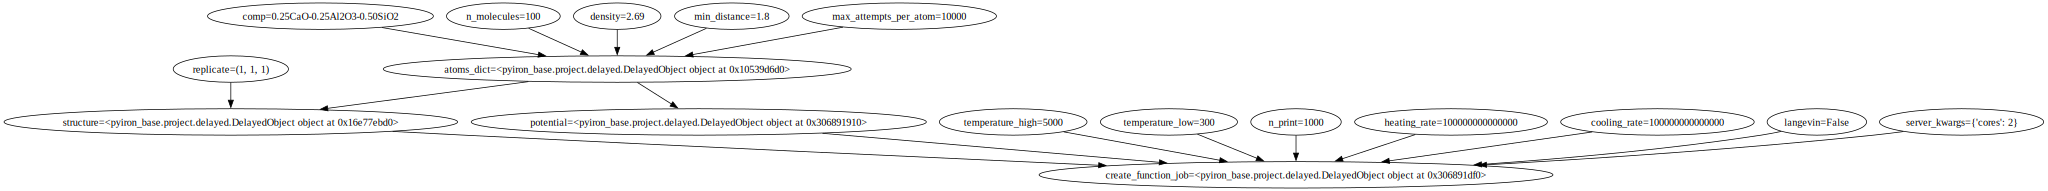

In [4]:
delayed.draw()

In [5]:
# Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
result = delayed.pull()

The job get_structure_dict_49fad8333b017bb4e945165bd30efa21 was saved and received the ID: 275
The job get_ase_structure_ba1e155d38e63994da39610f3c65f6b2 was saved and received the ID: 276
The job generate_potential_38a687283dcb7f1fa06fea438bad5ef5 was saved and received the ID: 277
The job melt_quench_simulation_2283a8a2932b130d30bfeeb5af02bae3 was saved and received the ID: 278


/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='o

299.6 K


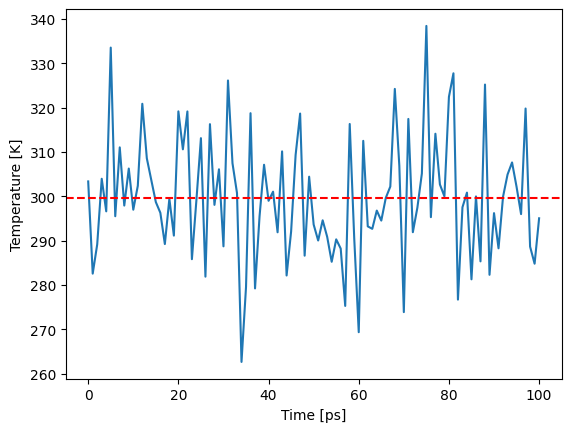

In [6]:
# Compute teh mean temperature of the last part of the simulation
mean_temp = np.mean(result["generic"]["temperature"])
print(f"{mean_temp:.1f} K")

# Plot the temperature and the mean temperature
plt.plot(result["generic"]["steps"] * 1e-3, result["generic"]["temperature"])
plt.axhline(np.mean(result["generic"]["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

In [7]:
print(result["structure"])

Atoms(symbols='Al50Ca25O200Si50', pbc=True, cell=[[15.94920709208325, 2.9298218121387025e-15, 2.929821812138703e-15], [-1.953214541293142e-15, 15.949207091, 2.9298218119397127e-15], [-1.9532145412931414e-15, -1.953214541293142e-15, 15.949207091]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


In [8]:
from ase import units
"# NBVAL_CHECK_OUTPUT"



V = np.mean(result["generic"]["volume"]) * 1e-24  # volume in cm#
massTot = result["structure"].get_masses().sum() / units._Nav

density = massTot / V
print(f"{(massTot / V):.2f} g/cm3")

2.85 g/cm3
